# Linear Model Selection and Regularization



The materials used in this tutorial are based on the applied exercises provided in the book "An Introduction to Statistical Learning with Applications in Python" (ISLP). We are trying to demonstrate how to implement the following methods of selecting the most appropriate model that explains the data:
   * Subset selection
   * Shrinkage: Lasso (L-1 regularization)
    
## 1. Subset Selection, Stepwise Selection and Lasso for selection features

Subset selection is an approach of identifying a subset of predictors (or attributes) that we believe have strong an association with the response variable. In this exercise, we will generate simulated data, and will use this data to perform best subset selection.

### 1.1 Generate simulated data
Here, we are going to use the <a href="https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html">random.normal()</a> function to generate a predictor $X$ of length $n = 100$, as well as a noise vector of length $n = 100$. Note that we start with setting the seed for the random number generate, the purpose of which is to make our analysis reproducible. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import time
import itertools

In [2]:
np.random.seed(1)

We first generate 100 random values that are normally distributed:

In [3]:
x = np.random.normal(size=100)

Then, generate some random noises as irreducible errors.

In [4]:
eps = np.random.normal(size=100)

Now we can have a look of the distribution for the generated data.

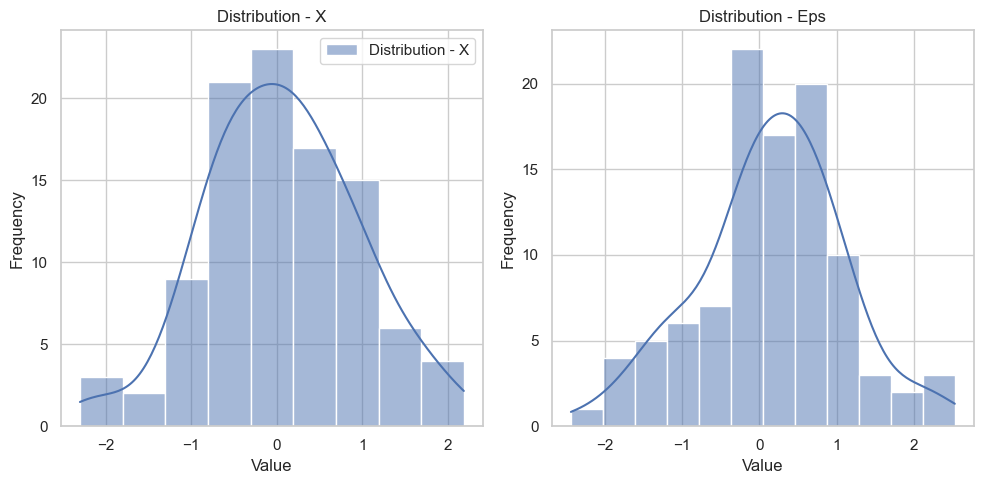

In [6]:
# Set up Seaborn style
sns.set(style="whitegrid")
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns
# Create a histogram using Seaborn for each distribution
sns.histplot(x, label="Distribution - X", kde=True, ax=axes[0])
sns.histplot(eps, label="Distribution - Eps", kde=True, ax=axes[1])
# Add labels and titles to each subplot
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution - X")

axes[1].set_xlabel("Value")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution - Eps")

# Add a legend to the first subplot
axes[0].legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

Now, we can generate a response vector $Y$ of length $n = 100$ according to the model 
    $Y = \beta_0+\beta_1 X +\beta_2 X^2 +\beta_3 X^3 + \epsilon $ 
where $\beta_0$, $\beta_1$, $\beta_2$ and $\beta_3$  are constants of your choice.
Here, we will set those coefficients as follows.

In [7]:
b0 = 2
b1 = 3
b2 = -1
b3 = 0.5

Given the coefficients, it is not hard to generate the simulated data using the polynomial function.

In [8]:
y = b0 + b1 * x + b2 * x ** 2 + b3 * x ** 3 + eps
y

array([ 5.93032555e+00,  9.00518886e-01,  4.66340163e-01, -2.39422283e+00,
        3.07644570e+00, -1.61280318e+01,  7.58654828e+00, -2.03729257e+00,
        2.60534969e+00,  1.21456421e+00,  4.43826452e+00, -1.24812462e+01,
        1.75819809e+00, -1.87500328e-01,  5.19511357e+00, -4.48702068e+00,
        1.41172511e+00, -3.35823740e+00,  3.24631456e+00,  3.91665607e+00,
       -3.20446150e+00,  4.09863575e+00,  5.53209841e+00,  5.28552426e+00,
        2.39858551e+00,  5.57680824e-01,  3.24295012e+00, -1.75467105e+00,
       -8.43086576e-02,  4.24772317e+00, -8.99740535e-01,  1.71782775e-02,
       -1.92602620e+00, -1.00134787e+00,  1.77274961e-01,  1.33831407e+00,
       -2.77715242e+00,  1.51039564e+00,  7.31265471e+00,  3.92636596e+00,
        1.19759283e+00, -1.90219279e+00, -1.39383124e-01,  7.38730853e+00,
        2.67937274e+00, -3.08283960e-01,  2.61759817e+00,  9.14026197e+00,
        2.57940068e+00,  4.27077963e+00,  2.51381497e+00, -1.63752083e+00,
       -2.43976965e+00,  

### 1.2  Perform best subset selection 
In this task, we will use the `combinations()` function from `itertools` library in Python (refer to the documentation of <a href="https://docs.python.org/3/library/itertools.html">itertools</a> for the function specification) to perform best subset selection in order to choose the best model containing the predictors $X$, $X^2$, $\dots$, $X^{10}$. What is the best model obtained according to $C_p$, $BIC$, and adjusted $R^2$? Show some plots to provide evidence for your answer, and report the coefficients of the best model obtained. Note you will need to use the <a href="https://stat.ethz.ch/R-manual/R-devel/library/base/html/data.frame.html">data.frame()</a> function to create a single data set containing both $X$ and $Y$.

### 1.2.1 Preprocessing the data to be used in the best subset selection

In [9]:
from itertools import combinations
# Demonstration of the method combinations
for comb_example in combinations(range(10), 3):
    print(comb_example)

(0, 1, 2)
(0, 1, 3)
(0, 1, 4)
(0, 1, 5)
(0, 1, 6)
(0, 1, 7)
(0, 1, 8)
(0, 1, 9)
(0, 2, 3)
(0, 2, 4)
(0, 2, 5)
(0, 2, 6)
(0, 2, 7)
(0, 2, 8)
(0, 2, 9)
(0, 3, 4)
(0, 3, 5)
(0, 3, 6)
(0, 3, 7)
(0, 3, 8)
(0, 3, 9)
(0, 4, 5)
(0, 4, 6)
(0, 4, 7)
(0, 4, 8)
(0, 4, 9)
(0, 5, 6)
(0, 5, 7)
(0, 5, 8)
(0, 5, 9)
(0, 6, 7)
(0, 6, 8)
(0, 6, 9)
(0, 7, 8)
(0, 7, 9)
(0, 8, 9)
(1, 2, 3)
(1, 2, 4)
(1, 2, 5)
(1, 2, 6)
(1, 2, 7)
(1, 2, 8)
(1, 2, 9)
(1, 3, 4)
(1, 3, 5)
(1, 3, 6)
(1, 3, 7)
(1, 3, 8)
(1, 3, 9)
(1, 4, 5)
(1, 4, 6)
(1, 4, 7)
(1, 4, 8)
(1, 4, 9)
(1, 5, 6)
(1, 5, 7)
(1, 5, 8)
(1, 5, 9)
(1, 6, 7)
(1, 6, 8)
(1, 6, 9)
(1, 7, 8)
(1, 7, 9)
(1, 8, 9)
(2, 3, 4)
(2, 3, 5)
(2, 3, 6)
(2, 3, 7)
(2, 3, 8)
(2, 3, 9)
(2, 4, 5)
(2, 4, 6)
(2, 4, 7)
(2, 4, 8)
(2, 4, 9)
(2, 5, 6)
(2, 5, 7)
(2, 5, 8)
(2, 5, 9)
(2, 6, 7)
(2, 6, 8)
(2, 6, 9)
(2, 7, 8)
(2, 7, 9)
(2, 8, 9)
(3, 4, 5)
(3, 4, 6)
(3, 4, 7)
(3, 4, 8)
(3, 4, 9)
(3, 5, 6)
(3, 5, 7)
(3, 5, 8)
(3, 5, 9)
(3, 6, 7)
(3, 6, 8)
(3, 6, 9)
(3, 7, 8)
(3, 7, 9)
(3, 8, 9)


Then, put our data into a data frame,

In [10]:
all_df = pd.DataFrame({'y': y, 'x': x})
all_df.head()

,y,x
0,5.930326,1.624345
1,0.900519,-0.611756
2,0.466340,-0.528172
3,-2.394223,-1.072969
4,3.076446,0.865408


Now, let's have a look at our data.

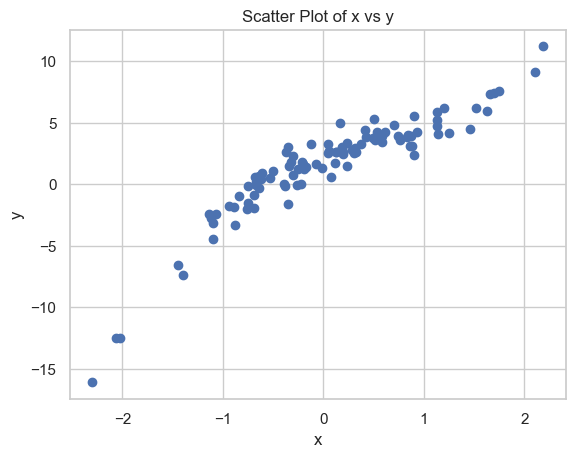

In [11]:
# Create a scatter plot
plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot of x vs y')
plt.show()

It seems that the plot shows the relationship between $X$ and $Y$ is linear. However, it is indeed not, as our data were generated from a polynomial function with degree 3. Our goal here is to find the best model contains at most 10 variables, from $X$ to $X^{10}$. Thus, the model formula for the full model is
$\hat{Y} = \beta_0 + \beta_1 X + \beta_2 X^2 + \dots + \beta_{10} x^{10}$. We should have all variables in the dataframe.

We should also specify the data and the maximum size of subset to examine, which is 10 here.

There are several ways could be used to generate Polynomial features.

1. Manually calculate the value from x with different degree

2.  We can use the <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html">PolynomialFeatures</a> function from `sklearn.preprocessing` library. 

In [12]:
# 1. Manually calculate Add columns with names 'x', 'x**2', ..., 'x**10'
all_df_manual = all_df.copy()
for i in range(2, 11):
    all_df_manual['x**' + str(i)] = all_df_manual['x'] ** i
all_df_manual.head()

,y,x,x**2,x**3,x**4,x**5,x**6,x**7,x**8,x**9,x**10
0,5.930326,1.624345,2.638498,4.285832,6.961671,11.308158,18.368354,29.836551,48.464863,78.723675,127.874436
1,0.900519,-0.611756,0.374246,-0.228947,0.140060,-0.085683,0.052417,-0.032066,0.019617,-0.012001,0.007342
2,0.466340,-0.528172,0.278965,-0.147342,0.077822,-0.041103,0.021710,-0.011466,0.006056,-0.003199,0.001689
3,-2.394223,-1.072969,1.151262,-1.235268,1.325403,-1.422116,1.525886,-1.637228,1.756694,-1.884878,2.022415
4,3.076446,0.865408,0.748930,0.648130,0.560897,0.485404,0.420073,0.363534,0.314605,0.272262,0.235617


In [13]:
# 2. Using PolynomialFeatures from sklearn.preprocessing
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=10, include_bias=False)
all_poly_values = poly_features.fit_transform(all_df[['x']])
all_df_poly = pd.DataFrame(all_poly_values, columns=['x**' + str(i) for i in range(1, 11)])
all_df_poly.head()

,x**1,x**2,x**3,x**4,x**5,x**6,x**7,x**8,x**9,x**10
0,1.624345,2.638498,4.285832,6.961671,11.308158,18.368354,29.836551,48.464863,78.723675,127.874436
1,-0.611756,0.374246,-0.228947,0.140060,-0.085683,0.052417,-0.032066,0.019617,-0.012001,0.007342
2,-0.528172,0.278965,-0.147342,0.077822,-0.041103,0.021710,-0.011466,0.006056,-0.003199,0.001689
3,-1.072969,1.151262,-1.235268,1.325403,-1.422116,1.525886,-1.637228,1.756694,-1.884878,2.022415
4,0.865408,0.748930,0.648130,0.560897,0.485404,0.420073,0.363534,0.314605,0.272262,0.235617


### 1.2.2 Perform best subset selection

Follow the tutorial in http://www.science.smith.edu/~jcrouser/SDS293/labs/lab8-py.html for subset selection.

In [14]:
# Define a function to evaluate the performance of a subset of predictors.
def evaluate_subset(X, y, feature_set):
    # Fit model on feature_set and calculate RSS
    model = sm.OLS(y,X[list(feature_set)])
    regr = model.fit()
    RSS = ((regr.predict(X[list(feature_set)]) - y) ** 2).sum()
    return {"model":regr, "RSS":RSS}

In [15]:
# Evaluate the models with k variables and select the one with lowest RSS.
def getBest(X, y, k):
    
    tic = time.time()
    
    results = []
    
    for combo in itertools.combinations(X.columns, k):
        results.append(evaluate_subset(X, y, combo))
    
    # Wrap everything up in a nice dataframe
    models = pd.DataFrame(results)
    
    # Choose the model with the lowest RSS
    best_model = models.loc[models['RSS'].argmin()]
    
    toc = time.time()
    print("Processed", models.shape[0], "models on", k, "predictors:", best_model['model'].params.keys().values, " in", (toc-tic), "seconds.")
    
    # Return the best model, along with some other useful information about the model
    return best_model

In [16]:
models_best = pd.DataFrame(columns=["RSS", "model"])

tic = time.time()
for i in range(1,11):
    models_best.loc[i] = getBest(all_df_poly, y, i)

toc = time.time()
print("Total elapsed time:", (toc-tic), "seconds.")

Processed 10 models on 1 predictors: ['x**1']  in 0.03735804557800293 seconds.
Processed 45 models on 2 predictors: ['x**1' 'x**3']  in 0.08259415626525879 seconds.
Processed 120 models on 3 predictors: ['x**1' 'x**3' 'x**6']  in 0.20515942573547363 seconds.
Processed 210 models on 4 predictors: ['x**1' 'x**2' 'x**3' 'x**4']  in 0.3643531799316406 seconds.
Processed 252 models on 5 predictors: ['x**1' 'x**2' 'x**3' 'x**4' 'x**6']  in 0.44034481048583984 seconds.
Processed 210 models on 6 predictors: ['x**1' 'x**2' 'x**3' 'x**4' 'x**6' 'x**8']  in 0.38422393798828125 seconds.
Processed 120 models on 7 predictors: ['x**1' 'x**2' 'x**4' 'x**6' 'x**8' 'x**9' 'x**10']  in 0.2091050148010254 seconds.
Processed 45 models on 8 predictors: ['x**1' 'x**2' 'x**3' 'x**4' 'x**6' 'x**8' 'x**9' 'x**10']  in 0.08831977844238281 seconds.
Processed 10 models on 9 predictors: ['x**1' 'x**2' 'x**4' 'x**5' 'x**6' 'x**7' 'x**8' 'x**9' 'x**10']  in 0.019357681274414062 seconds.
Processed 1 models on 10 predi

In [17]:
models_best.shape

(10, 2)

In [18]:
# Mallow's Cp
num_vars = models_best["RSS"].index.values
n = all_df_poly.shape[0]
rss = models_best["RSS"]
sample_variance = rss/ (n - num_vars - 1)
Cp = pd.to_numeric((1/n) *(rss + 2 * num_vars * sample_variance))

Text(0, 0.5, 'BIC')

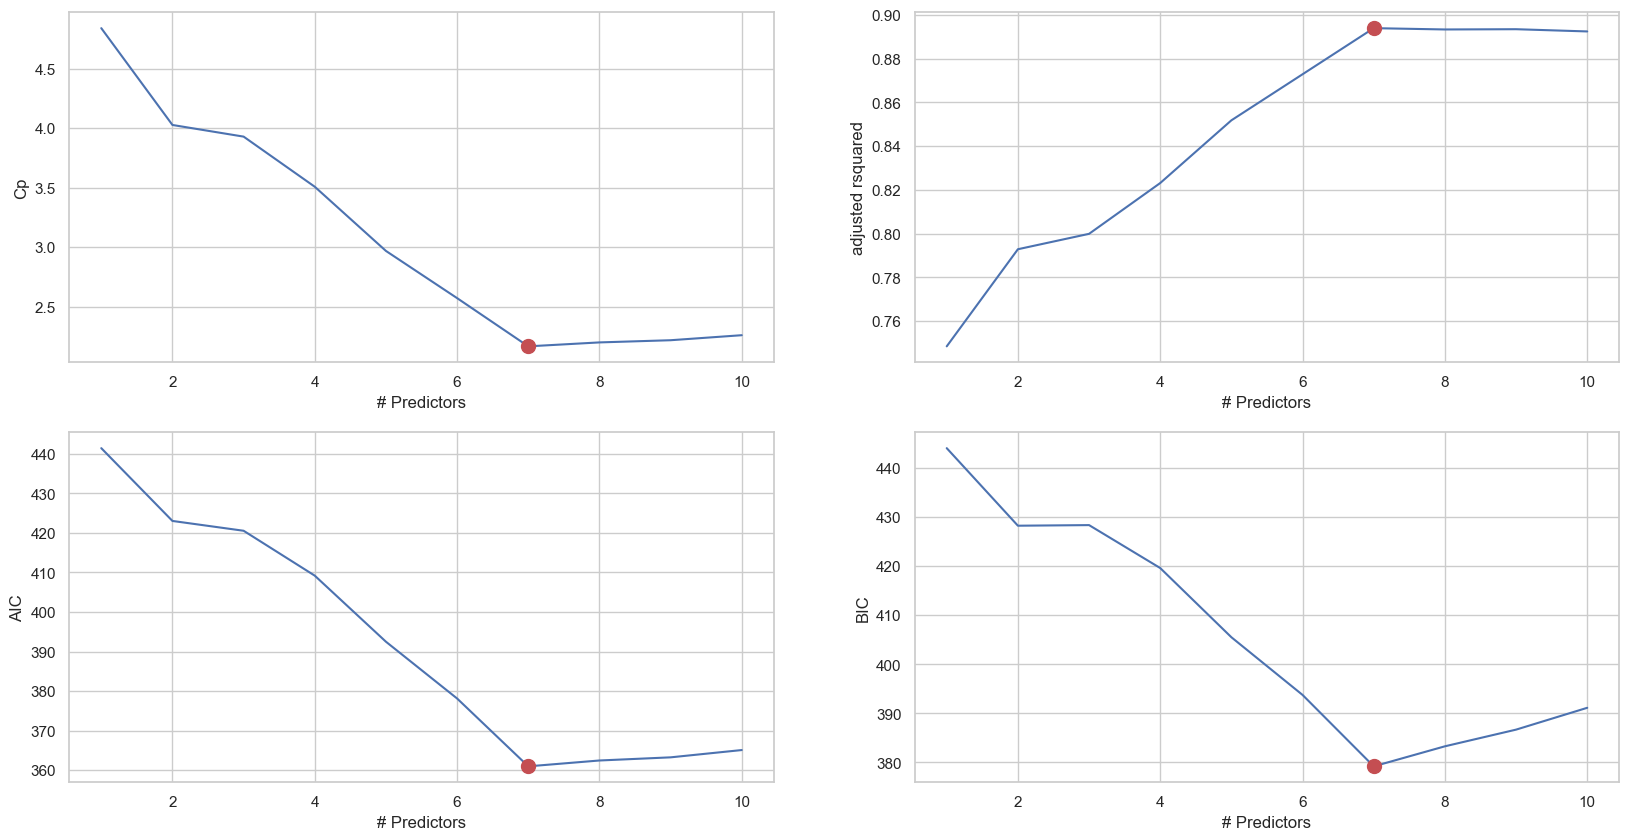

In [19]:
plt.figure(figsize=(20,10))
plt.rcParams.update({'font.size': 18, 'lines.markersize': 10})

# Set up a 2x2 grid so we can look at 4 plots at once
plt.subplot(2, 2, 1)

# The argmax() function can be used to identify the location of the maximum point of a vector
plt.plot(Cp)
plt.plot(Cp.argmin() + 1, Cp.min(), "or")
plt.xlabel('# Predictors')
plt.ylabel('Cp')

# We will now plot a red dot to indicate the model with the largest adjusted R^2 statistic.
# The argmax() function can be used to identify the location of the maximum point of a vector

rsquared_adj = models_best.apply(lambda row: row[1].rsquared_adj, axis=1)

plt.subplot(2, 2, 2)
plt.plot(rsquared_adj)
plt.plot(rsquared_adj.argmax() + 1, rsquared_adj.max(), "or")
plt.xlabel('# Predictors')
plt.ylabel('adjusted rsquared')

# We'll do the same for AIC and BIC, this time looking for the models with the SMALLEST statistic
aic = models_best.apply(lambda row: row[1].aic, axis=1)

plt.subplot(2, 2, 3)
plt.plot(aic)
plt.plot(aic.argmin() + 1, aic.min(), "or")
plt.xlabel('# Predictors')
plt.ylabel('AIC')

bic = models_best.apply(lambda row: row[1].bic, axis=1)

plt.subplot(2, 2, 4)
plt.plot(bic)
plt.plot(bic.argmin() + 1, bic.min(), "or")
plt.xlabel('# Predictors')
plt.ylabel('BIC')

Text(0, 0.5, 'RSS')

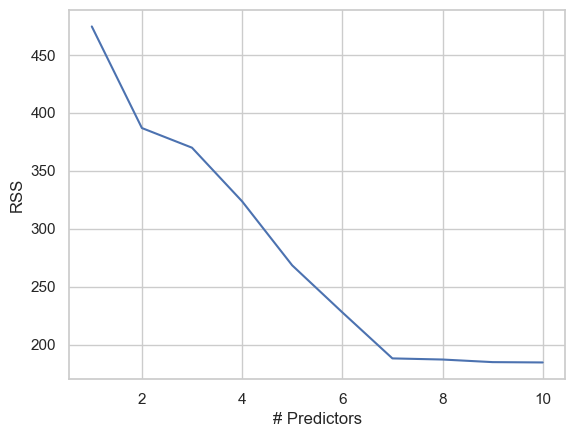

In [20]:
plt.plot(models_best["RSS"])
plt.xlabel('# Predictors')
plt.ylabel('RSS')

Using `summary()` function to see the result of the best subset selection.

In [21]:
models_best.loc[7,"model"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.901
Model:                            OLS   Adj. R-squared (uncentered):              0.894
Method:                 Least Squares   F-statistic:                              121.3
Date:                Mon, 11 Aug 2025   Prob (F-statistic):                    6.52e-44
Time:                        01:58:31   Log-Likelihood:                         -173.47
No. Observations:                 100   AIC:                                      360.9
Df Residuals:                      93   BIC:                                      379.2
Df Model:                           7                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x**1           3.5287      0.212     16.619      0.000       3.107       3.950
x**2          12.2737      1.381      8.886      0.000       9.531      15.017
x**4         -20.3197      2.746     -7.399      0.000     -25.774     -14.866
x**6          11.3516      1.733      6.550      0.000       7.910      14.793
x**8          -2.5841      0.426     -6.062      0.000      -3.431      -1.738
x**9           0.0058      0.001      6.199      0.000       0.004       0.008
x**10          0.2050      0.036      5.736      0.000       0.134       0.276
==============================================================================
Omnibus:                        0.632   Durbin-Watson:                   1.848
Prob(Omnibus):                  0.729   Jarque-Bera (JB):                0.645
Skew:                           0.184   Prob(JB):                        0.724
Kurtosis:                       2.862   Cond. No.                     1.40e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 1.4e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

All metrics, including AIC, Cp, BIC, select the best subset with 7 features. The p-values for x8 and x10 are significantly greater than that of the other selected features. However, RSS cannot help feature selection, because it is monotonically decreasing as the number of variables increases. 

## 1.3 Stepwise Selection

`mlxtend` is a popular Python library for machine learning and data analysis. It provides a wide range of tools and functionalities to enhance your machine learning workflows.

`mlxtend` provides methods for feature selection, including Sequential Feature Selection (SFS), Sequential Backward Selection (SBS), and more.

To get started with mlxtend, you can install it using `pip`:

In [22]:
# !pip install mlxtend

Here's a simple example of using `mlxtend` to perform Sequential Forward Selection (SFS) for feature selection:

In [23]:
from sklearn.preprocessing import PolynomialFeatures
from mlxtend.feature_selection import SequentialFeatureSelector

In [24]:
all_df_poly.head()

,x**1,x**2,x**3,x**4,x**5,x**6,x**7,x**8,x**9,x**10
0,1.624345,2.638498,4.285832,6.961671,11.308158,18.368354,29.836551,48.464863,78.723675,127.874436
1,-0.611756,0.374246,-0.228947,0.140060,-0.085683,0.052417,-0.032066,0.019617,-0.012001,0.007342
2,-0.528172,0.278965,-0.147342,0.077822,-0.041103,0.021710,-0.011466,0.006056,-0.003199,0.001689
3,-1.072969,1.151262,-1.235268,1.325403,-1.422116,1.525886,-1.637228,1.756694,-1.884878,2.022415
4,0.865408,0.748930,0.648130,0.560897,0.485404,0.420073,0.363534,0.314605,0.272262,0.235617


In [28]:
from sklearn.linear_model import LinearRegression
# Create a LinearRegression model
model = LinearRegression()
# Forward feature selection
regfit_fwd = SequentialFeatureSelector(model, k_features=7, forward=True, 
scoring='neg_mean_squared_error', cv=5)
regfit_fwd.fit(all_df_poly, y)

# Selected feature indices
selected_indices = regfit_fwd.k_feature_idx_

# Print selected feature indices
print("Selected feature indices:", selected_indices)

Selected feature indices: (0, 1, 2, 3, 4, 5, 7)


In [29]:
# Print selected feature names
best_feat_names = [all_df_poly.columns[i] for i in list(selected_indices)]
best_feat_names

['x**1', 'x**2', 'x**3', 'x**4', 'x**5', 'x**6', 'x**8']

Compare with model using best subset selection, we can see that some features are not selected by the model above. Try to set forward=False, what you will observe?

## 1.4 Perform Lasso
What we have done so far is about selecting the best subset of variables used in the model, which is often known as feature selection. As discussed in the lecture, the Lasso is one approach that we often used in machine learning to perform feature selection automatically. Depending on the shrinkage parameter, Lasso regularizes the coefficient in a way such that the estimated coefficients can be shrunk toward zero. The Python library that we are going to use is the <font color="orange">Scikit-Learn</font>. The main function that we are going to use is <font color="blue">Lasso</font> and <font color="blue">LassoCV()</font>.

Now we are ready to fit a lasso model to the simulated data, again using $X$,$X_2$, $\dots$, $X_{10}$ as predictors. Use cross-validation to select the optimal value of $\lambda$. Create plots of the cross-validation error as a function of $\lambda$. Report the resulting coefficient estimates, and discuss the results obtained.


Now, we fit a lasso model with cross-validation using the <font color="blue">LassoCV</font> function

In [30]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

In [37]:
# Standardize the features
scaler = StandardScaler()
xmat_scaled = scaler.fit_transform(all_df_poly)
# Create LassoCV model with cross-validation
lasso_cv = LassoCV(alphas=np.logspace(-3, 1, 13), cv=KFold(n_splits=5, shuffle=True, random_state=42), max_iter=100000)

# Fit the LassoCV model
lasso_cv.fit(xmat_scaled, y)

# Print the optimal alpha
print("Optimal alpha:", lasso_cv.alpha_)

Optimal alpha: 0.004641588833612777


Plot the MSE as a function of the logarithm of $\lambda$ with error bars.

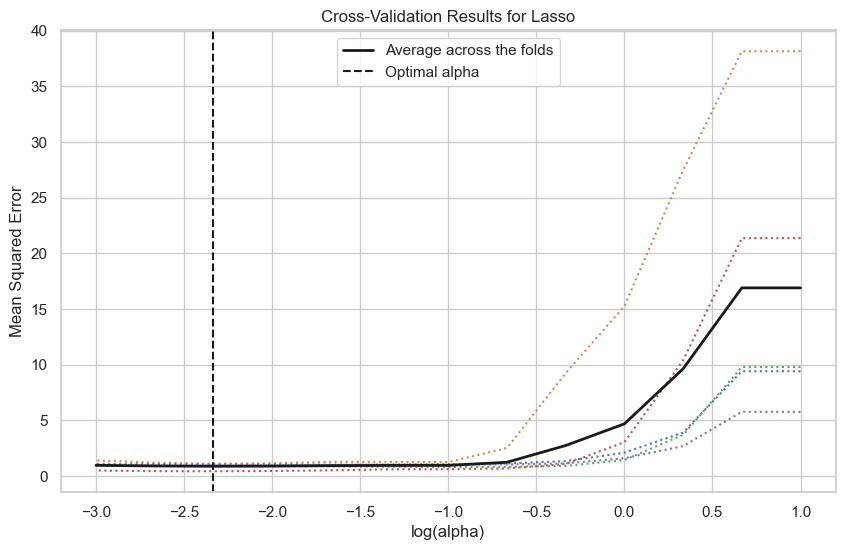

In [38]:
# Plot the cross-validation results
plt.figure(figsize=(10, 6))
plt.plot(np.log10(lasso_cv.alphas_), lasso_cv.mse_path_, ':')
plt.plot(np.log10(lasso_cv.alphas_), lasso_cv.mse_path_.mean(axis=1), 'k',
         label='Average across the folds', linewidth=2)
plt.axvline(np.log10(lasso_cv.alpha_), linestyle='--', color='k',
            label='Optimal alpha')
plt.legend()
plt.xlabel('log(alpha)')
plt.ylabel('Mean Squared Error')
plt.title('Cross-Validation Results for Lasso')
plt.show()

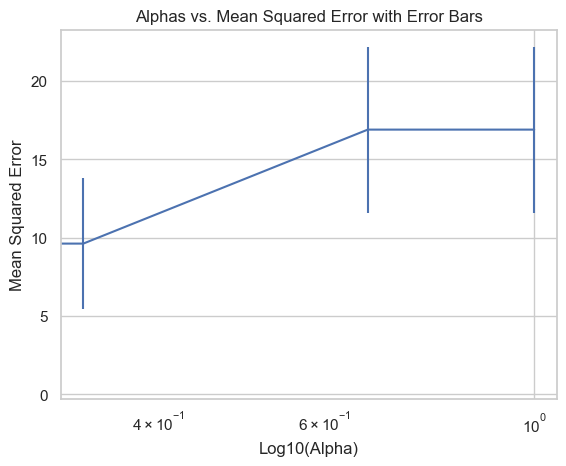

In [39]:
# Plot alphas vs. MSE with error bars
plt.errorbar(np.log10(lasso_cv.alphas_), lasso_cv.mse_path_.mean(axis=1), yerr=lasso_cv.mse_path_.std(axis=1) / np.sqrt(5))
plt.xlabel('Log10(Alpha)')
plt.ylabel('Mean Squared Error')
plt.title('Alphas vs. Mean Squared Error with Error Bars')
plt.xscale('log')
plt.show()

What is the cross-validated lambda value?

In [40]:
lasso_cv.alpha_

0.004641588833612777

Now we refit our lasso model using $\lambda$ chosen by cross-validation.

In [41]:
from sklearn.linear_model import Lasso, LassoCV
# Get the best alpha (regularization parameter)
best_alpha = lasso_cv.alpha_

# Fit the Lasso model with the best alpha
lasso_model = Lasso(alpha=best_alpha)
lasso_model.fit(xmat_scaled, y)

# Get the coefficient values
coefficients = lasso_model.coef_

# Print the first 11 coefficients
print(coefficients[:11])

[ 2.58308979 -1.45256681  1.5063442   0.          0.          0.43085468
  0.          0.          0.02119568 -0.        ]


In [42]:
# get the index of values the coefficients that are not zero
nonzero_indices = np.nonzero(coefficients)[0]
print(nonzero_indices)

[0 1 2 5 8]


In [43]:
# Print selected feature names
[all_df_poly.columns[i] for i in nonzero_indices]

['x**1', 'x**2', 'x**3', 'x**6', 'x**9']